<a href="https://colab.research.google.com/github/yudadaniela/daniela-ai-projects/blob/main/autoencoder/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder Para Mejorar Una Imagen.

 **El autoencoder tiene diferentes aplicaciones algunas son:**

*   Eliminación de ruido
*   Anonimización de datos

*   Criptografía y seguridad
*   Agrupamiento semántico

*   Generación de nuevos datos
*   Imputación de datos perdidos

*   Reducción de dimensionalidad
*   Identificación de anomalías


**El autoencoder tiene diferentes aplicaciones una de ellas es a la identificación de anomalías o  datos atípicos o  en ingles (outliers) es una observación que es numéricamente distante del resto de los datos.**

In [ ]:
%%html
<p style='text-align: justify;'> <b>El autoencoder tiene diferentes aplicaciones una de ellas es a la reducción de dimensionalidad. Ejemplo: en reducción de ruido de una imagen, primero la imagen de entrada, luego un codificador, se comprime la imagen y un decodificador. Al comprimir la imagen se tiene una reducción de dimensionalidad se queda con lo más representativo de la imagen</b> </p>

In [ ]:
%%html
<p style='text-align: justify;'> <b>Una aplicación del autoencoder es la reducción de ruido en una imagen, se debe tener un dato de entrada, luego un codificador, se comprime la imagen y un decodificador para que la imagen este sin ruido. En este caso el dato de entrada es una imagen con ruido y el dato de salida es la misma imagen sin ruido(ver imagen a continuación) </b> </p>


In [ ]:
%%html
<p style='text-align: justify;'> <b> El autoencoder lo podemos programar utilizando keras y tensorflow, importando la librería, las capas son layers, la capa de entrada tiene 784 neuronas(Cada imagen tiene 28 x 28 píxeles cuadrados 784 píxeles en total por cada imágen), después se comprime a 32 y luego descomprensión a 784. Utilizamos funciones de activación relu para la compresión y sigmoide para la descompresión. Se utiliza el codificador y decodificador en la imagen se muestra como se usa. layers[-1] significa la última capa, la de salida </b> </p>


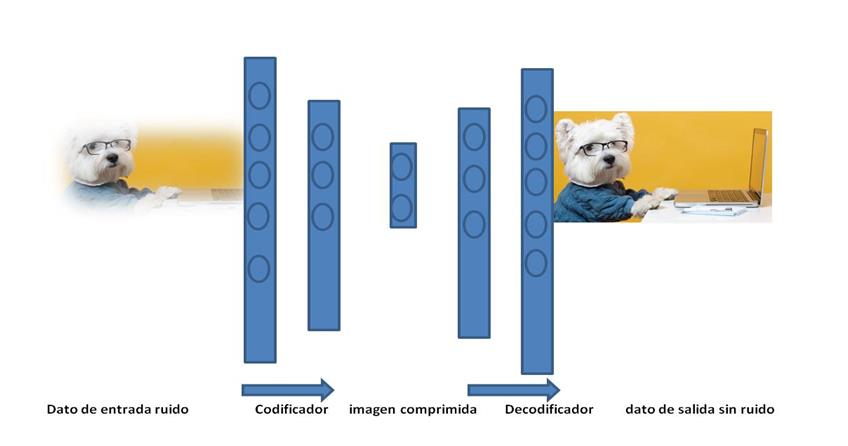

# Entrenar el modelo con keras y tensorflow

1. **Cargue las librerias que necesite:numpy, matplotlib.pyplot,etc.**


2. **Para cargar las librerias utilice  import seguido del nombre de la libreria y de un alias (as).Ejemplo import pandas as pd**


3.   **Ejecute de forma secuencial de arriba hacia abajo las celdas de código dando click al boton play o ctrl+enter**
   
4. **Al ejecutar la celda debe marcar un check en color verde al lado izquierdo de la celda de código y en el menu de google colab en la parte superior derecha, se debe activar Ram y Disco con un check verde.**


5. **El simbolo # es para comentarios dentro del código.**

6. **Para subir un archivo a google colab se puede hacer click en la parte izquierda, donde aparace una carpeta y le da click al simbolo de una hoja con la flecha hacia arriba cargar archivo al almacenamiento de sesión.**

Mnist un conjunto que esta dentro de keras.

Conjunto de números escritos a mano digitalizados.

Los números son:0,1,2,3,4,5,6,7,8,9

En total son 10 números.

Estos números estan en un dataset en keras.

Cada imagen tiene 28 x 28 píxeles cuadrados (784 píxeles en total por cada imágen). Se utiliza una división  del conjunto de datos para evaluar y comparar modelos, en la que se utilizan 60.000 imágenes para formar un modelo(training) y un conjunto separado de 10.000 imágenes para probarlo(test)

**Para guardar el modelo se instala la libreria h5py**

In [ ]:
pip install h5py

**Observemos las imágenes de los numeros en escala de grises**


1.   x_train:entrada de la red neuronal(entrenar la red)
2.   y_train:salida de la red neuronal(entrenar la red)
3. x_test:entrada de prueba del red neuronal(probrando la red neuronal)
4. y_test:salida de prueba de la red neuronal(probrando la red neuronal)
5. mnist.load_data():Carga los números



Para graficar los números.

* Se puede escribir subplot(224) ó subplot(2,2,4)
* Especifica num_filas, num_columnas, numplot



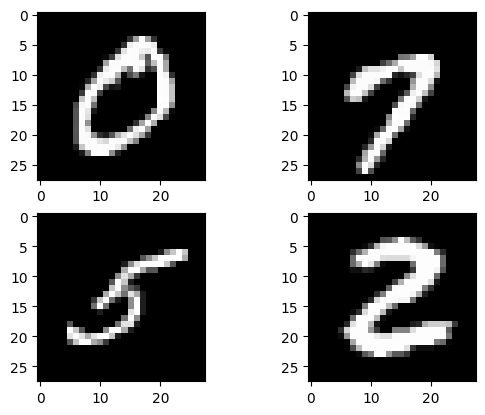

In [ ]:
from keras.datasets import mnist
import matplotlib.pyplot as plt
# cargar (descargar si es necesario) el conjunto de datos MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# plot 4 imagenes en escala de grises
plt.subplot(2,2,1)
plt.imshow(x_train[1], cmap=plt.get_cmap('gray'))
plt.subplot(2,2,2)
plt.imshow(x_train[15], cmap=plt.get_cmap('gray'))
plt.subplot(2,2,3)
plt.imshow(x_train[35], cmap=plt.get_cmap('gray'))
plt.subplot(224)
plt.imshow(x_train[25], cmap=plt.get_cmap('gray'))
# Muestra el gráfico de los 4 numeros
plt.show()

**Cargamos las capas del autoencoder**

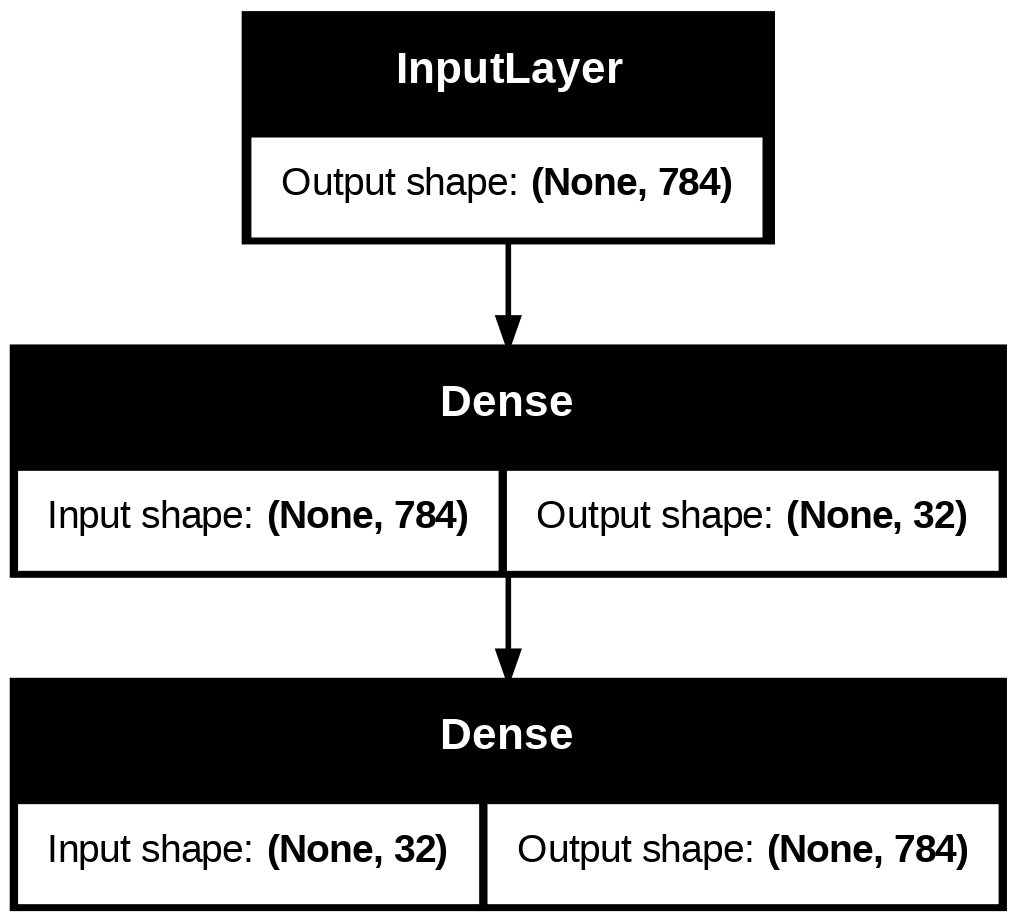

In [ ]:
import keras
from keras.datasets import mnist
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model


entrada = keras.Input(shape=(784,))
codificación = layers.Dense(32, activation='relu')(entrada)
salida = layers.Dense(784, activation='sigmoid')(codificación)

autoencoder = keras.Model(entrada, salida)

codificador = keras.Model(entrada, codificación)
entradacodifi = keras.Input(shape=(32,))
capadescodifi = autoencoder.layers[-1]
descodifi = keras.Model(entradacodifi, capadescodifi(entradacodifi))

plot_model(autoencoder, show_shapes=True, show_layer_names=False)



**Miremos las capas del modelo de red neuronal densa artificial autoencoder**

In [ ]:
print(autoencoder.summary())

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

None


**Compilamos el modelo mediante model.compile() y colocando el algoritmo de optimización y la función de pérdida**

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
%%html
<p style='text-align: justify;'> <b> Cargamos el conjunto de datos MNIST, una parte para  training y la otra para test y normalizamos dividiendo por 255 pixeles(los valores de los pixeles estan entre 0 y 255) asi quedan los valores en el intervalo [0,1]. Se elimina la etiqueta,descartándola al leer el conjunto de datos</b> </p>


In [ ]:
from keras.datasets import mnist
import numpy as np
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
%%html
<p style='text-align: justify;'> <b>Procedemos a entrenar el autoencoder usando el dataset de  MNIST,con las imagenes de los numeros del 0 al 9 digitalizados, estableciendo como datos de salida, con los que hay que comparar, los mismos datos de entrada (para mirar algun cambio cuando se otro tipo de dato,conocer muy bien el dato inicial), y fijando el número de epochs, tamaño de lote(batch_size). </b> </p>


**Por eso apararece x_train, dos veces, entrada el dato , salida el mismo dato**

In [ ]:
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,validation_data=(x_test, x_test))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.2772 - val_loss: 0.1926
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1734 - val_loss: 0.1563
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1466 - val_loss: 0.1356
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1299 - val_loss: 0.1223
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1192 - val_loss: 0.1137
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1120 - val_loss: 0.1078
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1068 - val_loss: 0.1034
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1030 - val_loss: 0.1001
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1002 - val_loss: 0.0978
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0982 - val_loss: 0.0962


**Miremos las capas del modelo de la red neuronal densa artificial autoencoder**

In [ ]:
print(autoencoder.summary())

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,978 (597.57 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,986 (398.39 KB)

None


In [ ]:
%%html
<p style='text-align: justify;'> <b> Tomamos  4 imagenes de los números (0,1,2,3,4,5,6,7,8,9)escrito a mano digitalizados  de MNIST, los pasamos por el codificador y luego por el descodificador, quedándonos tanto con la imagen original, la reconstrucción y también la codificación interna de 32 bytes para representarlos gráficamente y poder compararlos.</b> </p>


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


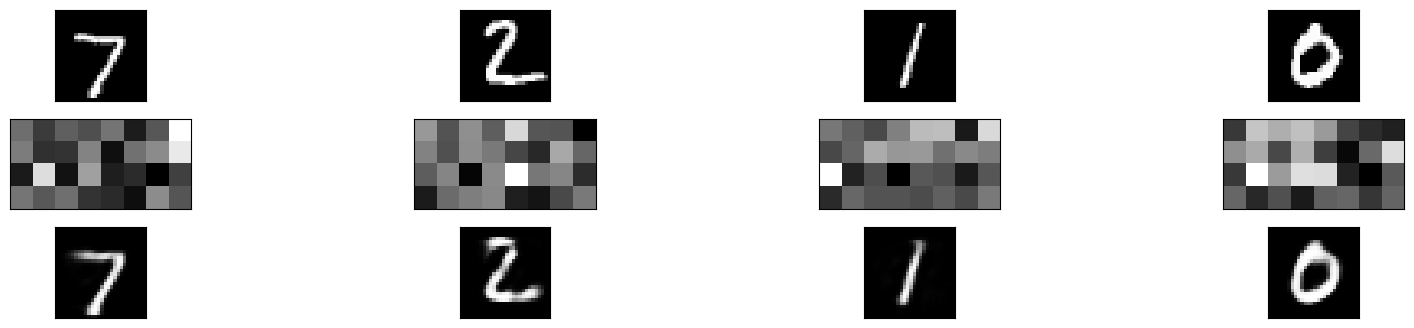

In [ ]:
encoded_imgs = codificador.predict(x_test)
decoded_imgs = descodifi.predict(encoded_imgs)

import matplotlib.pyplot as plt

n = 4  # Cuantos digitos(digitalizados) vamos a mostrar del dataset de Mnist
plt.figure(figsize=(20, 4))
for i in range(n):# recorre en este caso dependiendo del valor de n=4
                  #En este caso i=0,1,2,3
    # Muestras las imagenes originales
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(8, 4).T)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Muestra las imagenes reconstruidas utilizando el decodificador
    ax = plt.subplot(3, n, i + 1 + n*2)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# **Realice lo siguiente:**
**Cambia el valor de n, ejemplo n=5, mire el gráfico antes de autoencoder y despues del autoencoder.Debe mostrar el gráfico de 5 numeros. Antes y despues del autoencoder**


*   Modifique el tipo de optimizador diferente a optimizer='adam'
*   Modifique los valores de learning rate, ejemplo lr=0.001

*   Modifique epochs,batch_size,ejemplo epochs=10, batch_size=200

*   Agregue una capa oculta al modelo con 256 neuronas.

*   Modifique Dropout, ejemplo Dropout=0.2. Esto permite excluir aleatoriamente el 20% de las neuronas en el entrenamiento para evitar el sobreajuste


*   Modifique loss dentro de model.compile(), diferente a loss='categorical_crossentropy'

*   Imprima las capas de neuronas del modelo print(model.summary())

*   Guarde el modelo model.save('modeloinicial.h5')# pip install h5py

*  Guarde los pesos del modelo mediante: model.save_weights('model_pesos.h5')



###

In [ ]:
# Escriba aqui el código que responde a lo solicitado  agregue mas celdas de código si lo necesita.
import keras
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model

entrada = keras.Input(shape=(784,))

# La Capa oculta adicional de 256 neuronas
capa_oculta = layers.Dense(256, activation='relu')(entrada)

# Dropout del 20% para evitar el sobreajuste
dropout = layers.Dropout(0.2)(capa_oculta)

# Codificación a 32 neuronas
codificacion = layers.Dense(32, activation='relu')(dropout)

# Decodificación a 784 neuronas
salida = layers.Dense(784, activation='sigmoid')(codificacion)

autoencoder = keras.Model(entrada, salida)
codificador = keras.Model(entrada, codificacion)

entrada_codifi = keras.Input(shape=(32,))
capa_descodifi = autoencoder.layers[-1]
descodifi = keras.Model(entrada_codifi, capa_descodifi(entrada_codifi))

print(autoencoder.summary())

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,056 (918.19 KB)

 Trainable params: 235,056 (918.19 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
from tensorflow.keras.optimizers import SGD

#Cambio de optimizador diferente de Adam
optimizador = SGD(learning_rate=0.01, momentum=0.9)

autoencoder.compile(
    optimizer=optimizador,
    loss='mean_squared_error'
)

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test  = x_test.reshape((len(x_test),  np.prod(x_test.shape[1:])))

print("Forma x_train:", x_train.shape)
print("Forma x_test: ", x_test.shape)

Forma x_train: (60000, 784)
Forma x_test:  (10000, 784)


In [ ]:
autoencoder.fit(
    x_train, x_train,
    epochs=50,
    batch_size=200,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0325 - val_loss: 0.0304
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0324 - val_loss: 0.0303
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0323 - val_loss: 0.0302
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0323 - val_loss: 0.0302
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0322 - val_loss: 0.0301
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0321 - val_loss: 0.0301
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0321 - val_loss: 0.0300
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0320 - val_loss: 0.0299
Epoch 9/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0320 - val_loss: 0.0299
Epoch 10/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0319 - val_loss: 0.0298
Epoch 11/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0319 - val_loss: 0.0298
Epoch 12/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


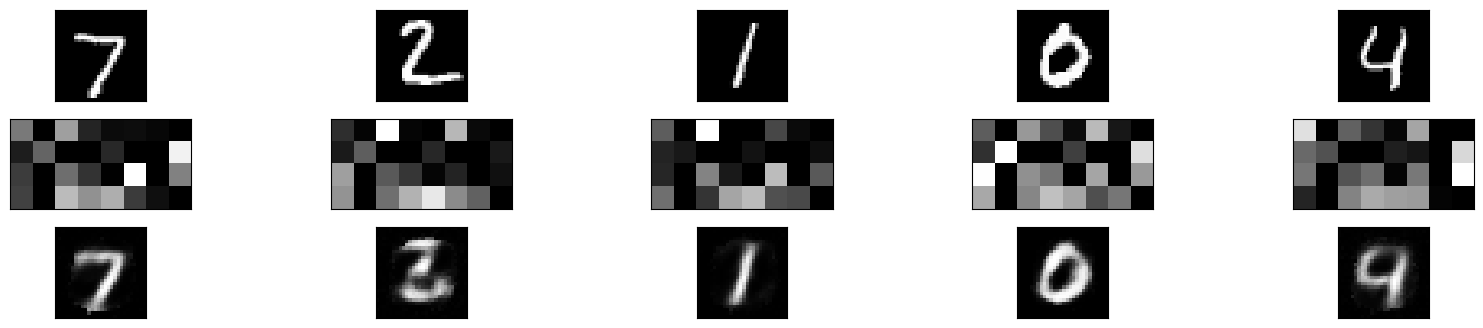

In [ ]:
encoded_imgs = codificador.predict(x_test)
decoded_imgs = descodifi.predict(encoded_imgs)

n = 5  # Mostrar 5 números

plt.figure(figsize=(20, 4))
for i in range(n):
    # Imagen original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Representación interna (codificada)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(8, 4).T)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Imagen reconstruida
    ax = plt.subplot(3, n, i + 1 + n * 2)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [ ]:
autoencoder.save('autoencoder_modelo.h5')
autoencoder.save_weights('autoencoder_pesos.weights.h5')
